In [8]:
import numpy as np
import matplotlib.pyplot as plt
import ripser
import persim
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
import gudhi as gd
from gudhi.representations import Landscape, Silhouette, PersistenceImage
import tadasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import networkx as nx
import nibabel as nib
import os
from tqdm import tqdm
from skimage.transform import resize
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve
import warnings
import time
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import svd
warnings.filterwarnings("ignore", category=UserWarning)

target_shape = (128, 128, 64)

In [2]:
data_dir = '/Users/dasidorov03/PycharmProjects/dploma_4_course/IXI-T1/data/'
target_shape = (128, 128, 64)

def load_mri_images(data_dir):
    images = []
    file_list = [f for f in os.listdir(data_dir) if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    for file_name in tqdm(file_list, desc="Загрузка MRI-изображений"):
        img_path = os.path.join(data_dir, file_name)
        img = nib.load(img_path)
        img_data = img.get_fdata()

        img_resized = resize(img_data, target_shape, anti_aliasing=True)

        img_vector = img_resized.flatten()
        images.append(img_vector)
    
    return np.array(images)

mri_data = load_mri_images(data_dir)


Загрузка MRI-изображений: 100%|██████████| 582/582 [01:58<00:00,  4.89it/s]


In [28]:
data_dir = '/Users/dasidorov03/PycharmProjects/dploma_4_course/IXI-T1/data/'
target_shape = (128, 128, 64)

def load_mri_images(data_dir):
    """
    Загрузка и предобработка МРТ-изображений
    """
    images = []
    file_names = []
    file_list = [f for f in os.listdir(data_dir) if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    for file_name in tqdm(file_list, desc="Загрузка MRI-изображений"):
        img_path = os.path.join(data_dir, file_name)
        img = nib.load(img_path)
        img_data = img.get_fdata()

        img_resized = resize(img_data, target_shape, anti_aliasing=True)

        # Нормализация интенсивности
        img_resized = (img_resized - np.min(img_resized)) / (np.max(img_resized) - np.min(img_resized))
        
        img_vector = img_resized.flatten()
        images.append(img_vector)
        file_names.append(file_name)
    
    return np.array(images), file_names

def reduce_dimension(data, n_components=30):
    """
    Снижение размерности данных с помощью PCA
    """
    print(f"Снижение размерности с {data.shape[1]} до {n_components}...")
    pca = PCA(n_components=n_components)
    return pca.fit_transform(data)

def compute_tangent_spaces(data, k=15, n_dim=10):
    """
    Вычисление локальных касательных пространств для каждой точки
    """
    print("Вычисление касательных пространств...")
    n_samples = data.shape[0]
    
    # Находим ближайших соседей
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(data)
    distances, indices = nbrs.kneighbors(data)
    
    # Исключаем саму точку из списка соседей
    indices = indices[:, 1:]
    
    # Хранилище для базисов касательных пространств
    tangent_bases = []
    
    for i in tqdm(range(n_samples), desc="Построение касательных пространств"):
        # Центрируем соседей относительно текущей точки
        neighbors = data[indices[i]]
        center = data[i]
        centered_neighbors = neighbors - center
        
        # SVD для получения базиса касательного пространства
        U, S, Vt = svd(centered_neighbors, full_matrices=False)
        
        # Берем первые n_dim столбцов как базис касательного пространства
        tangent_basis = Vt[:n_dim].T
        tangent_bases.append(tangent_basis)
    
    return tangent_bases, indices

def compute_connection_forms(tangent_bases, neighbor_indices):
    """
    Вычисление форм связности между касательными пространствами
    """
    n_samples = len(tangent_bases)
    connection_forms = {}
    
    for i in tqdm(range(n_samples), desc="Вычисление форм связности"):
        basis_i = tangent_bases[i]
        
        for j_idx, j in enumerate(neighbor_indices[i]):
            basis_j = tangent_bases[j]
            
            # Матрица связности: переход от базиса i к базису j
            connection_matrix = np.dot(basis_i.T, basis_j)
            
            # Сохраняем матрицу связности
            connection_forms[(i, j)] = connection_matrix
    
    return connection_forms

def compute_curvature(data, tangent_bases, neighbor_indices):
    """
    Вычисление локальной кривизны многообразия
    """
    n_samples = len(tangent_bases)
    curvature_scores = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Вычисление кривизны"):
        # Находим собственные значения ковариационной матрицы окрестности
        neighbors = data[neighbor_indices[i]]
        center = data[i]
        centered_neighbors = neighbors - center
        
        # Вычисляем ковариационную матрицу
        cov_matrix = np.dot(centered_neighbors.T, centered_neighbors)
        
        # Находим собственные значения
        eigenvalues = np.linalg.eigvalsh(cov_matrix)
        
        # Сортируем и оставляем только ненулевые собственные значения
        eigenvalues = eigenvalues[eigenvalues > 1e-10]
        
        if len(eigenvalues) > 1:
            # Кривизна как отношение минимального к максимальному собственному значению
            min_eig = np.min(eigenvalues)
            max_eig = np.max(eigenvalues)
            curvature_scores[i] = 1.0 - (min_eig / max_eig)
        else:
            curvature_scores[i] = 1.0  # Максимальная кривизна, если есть только одно ненулевое собственное значение
    
    # Нормализуем оценки кривизны
    if np.max(curvature_scores) > np.min(curvature_scores):
        curvature_scores = (curvature_scores - np.min(curvature_scores)) / (np.max(curvature_scores) - np.min(curvature_scores))
    
    return curvature_scores

def compute_holonomy(tangent_bases, neighbor_indices, connection_forms, n_paths=5, path_length=3):
    """
    Вычисление голономии через параллельный перенос по замкнутым путям
    """
    n_samples = len(tangent_bases)
    n_neighbors = neighbor_indices.shape[1]
    holonomy_scores = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Вычисление голономии"):
        local_holonomy = 0.0
        valid_paths = 0
        
        # Генерируем несколько случайных замкнутых путей
        for _ in range(n_paths):
            # Строим замкнутый путь начинающийся и заканчивающийся в точке i
            path = [i]
            current = i
            
            # Последовательно выбираем случайных соседей
            for step in range(path_length):
                # Выбираем случайного соседа
                next_idx = np.random.randint(0, n_neighbors)
                next_point = neighbor_indices[current][next_idx]
                
                path.append(next_point)
                current = next_point
            
            # Добавляем исходную точку, чтобы замкнуть путь
            path.append(i)
            
            # Вычисляем параллельный перенос вдоль пути через произведение матриц связности
            transport = np.eye(tangent_bases[0].shape[1])  # Начинаем с единичной матрицы
            valid_path = True
            
            for p in range(len(path) - 1):
                start = path[p]
                end = path[p + 1]
                
                # Проверяем наличие формы связности
                connection = connection_forms.get((start, end), None)
                if connection is None:
                    # Пробуем обратную связь
                    connection = connection_forms.get((end, start), None)
                    if connection is None:
                        valid_path = False
                        break
                    # Транспонируем матрицу для обратного направления
                    connection = connection.T
                
                # Обновляем матрицу параллельного переноса
                transport = np.dot(transport, connection)
            
            if valid_path:
                # Голономия - отклонение от единичной матрицы после параллельного переноса по замкнутому пути
                holonomy = np.linalg.norm(transport - np.eye(transport.shape[0]), 'fro')
                local_holonomy += holonomy
                valid_paths += 1
        
        if valid_paths > 0:
            holonomy_scores[i] = local_holonomy / valid_paths
        else:
            holonomy_scores[i] = 0
    
    # Нормализуем оценки голономии
    if np.max(holonomy_scores) > np.min(holonomy_scores):
        holonomy_scores = (holonomy_scores - np.min(holonomy_scores)) / (np.max(holonomy_scores) - np.min(holonomy_scores))
    
    return holonomy_scores

def compute_reconstruction_error(data, tangent_bases, neighbor_indices):
    """
    Вычисление ошибки реконструкции соседей через касательное пространство
    """
    n_samples = len(tangent_bases)
    reconstruction_errors = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Вычисление ошибки реконструкции"):
        neighbors = data[neighbor_indices[i]]
        center = data[i]
        tangent_space = tangent_bases[i]
        
        # Проецируем соседей на касательное пространство
        centered_neighbors = neighbors - center
        projection = np.dot(centered_neighbors, tangent_space)
        
        # Восстанавливаем из проекции
        reconstruction = center + np.dot(projection, tangent_space.T)
        
        # Вычисляем ошибку реконструкции
        errors = np.mean(np.square(neighbors - reconstruction), axis=1)
        reconstruction_errors[i] = np.mean(errors)
    
    # Нормализуем ошибки реконструкции
    if np.max(reconstruction_errors) > np.min(reconstruction_errors):
        reconstruction_errors = (reconstruction_errors - np.min(reconstruction_errors)) / (np.max(reconstruction_errors) - np.min(reconstruction_errors))
    
    return reconstruction_errors

def detect_anomalies(data, k=15, n_dim=10, n_pca=100, 
                     curvature_weight=0.4, holonomy_weight=0.3, reconstruction_weight=0.3):
    """
    Обнаружение аномалий с использованием метода расслоенных пространств
    """
    start_time = time.time()
    
    # Снижаем размерность данных для ускорения вычислений
    data_reduced = reduce_dimension(data, n_components=n_pca)
    
    # Вычисляем касательные пространства
    tangent_bases, neighbor_indices = compute_tangent_spaces(data_reduced, k=k, n_dim=n_dim)
    
    # Вычисляем формы связности
    connection_forms = compute_connection_forms(tangent_bases, neighbor_indices)
    
    # Вычисляем метрики аномальности
    curvature_scores = compute_curvature(data_reduced, tangent_bases, neighbor_indices)
    holonomy_scores = compute_holonomy(tangent_bases, neighbor_indices, connection_forms)
    reconstruction_errors = compute_reconstruction_error(data_reduced, tangent_bases, neighbor_indices)
    
    # Комбинируем метрики с заданными весами
    anomaly_scores = (curvature_weight * curvature_scores + 
                      holonomy_weight * holonomy_scores + 
                      reconstruction_weight * reconstruction_errors)
    
    end_time = time.time()
    print(f"Общее время выполнения: {end_time - start_time:.2f} секунд")
    
    return anomaly_scores, curvature_scores, holonomy_scores, reconstruction_errors

def visualize_anomalies(mri_data, file_names, anomaly_scores, top_n=10):
    """
    Визуализация топ-N аномалий
    """
    # Сортируем индексы по убыванию аномальности
    sorted_indices = np.argsort(anomaly_scores)[::-1]
    
    # Берем топ-N аномалий
    top_anomalies = sorted_indices[:top_n]
    
    print(f"\nТоп-{top_n} аномалий:")
    for i, idx in enumerate(top_anomalies):
        print(f"{i+1}. {file_names[idx]} (оценка: {anomaly_scores[idx]:.4f})")
    
    # Визуализация
    plt.figure(figsize=(15, 8))
    
    # Гистограмма оценок аномальности
    plt.subplot(1, 2, 1)
    plt.hist(anomaly_scores, bins=30, alpha=0.7)
    plt.axvline(x=anomaly_scores[top_anomalies[-1]], color='r', linestyle='--', 
                label=f'Порог топ-{top_n}')
    plt.xlabel('Оценка аномальности')
    plt.ylabel('Количество образцов')
    plt.title('Распределение оценок аномальности')
    plt.legend()
    
    # Выбор и отображение среза одной из топ аномалий
    plt.subplot(1, 2, 2)
    top_idx = top_anomalies[0]
    mri_volume = mri_data[top_idx].reshape(target_shape)
    central_slice = mri_volume[:, :, target_shape[2]//2]
    
    plt.imshow(central_slice, cmap='gray')
    plt.title(f'Центральный срез топ-аномалии: {file_names[top_idx]}')
    plt.colorbar()
    
    plt.tight_layout()
    plt.savefig('mri_anomalies.png')
    plt.show()

In [4]:
mri_data, file_names = load_mri_images(data_dir)

Загрузка MRI-изображений: 100%|██████████| 582/582 [02:02<00:00,  4.76it/s]


Снижение размерности с 1048576 до 100...
Вычисление касательных пространств...


Построение касательных пространств: 100%|██████████| 582/582 [00:00<00:00, 11925.07it/s]


Вычисление форм связности...


Вычисление форм связности: 100%|██████████| 582/582 [00:00<00:00, 10102.74it/s]


Оценка кривизны многообразия...


...

Вычисление голономии...


Вычисление голономии: 100%|██████████| 582/582 [00:00<00:00, 16406.68it/s]


Вычисление ошибки реконструкции...


Вычисление ошибки реконструкции: 100%|██████████| 582/582 [00:00<00:00, 38241.14it/s]


Общее время выполнения: 47.09 секунд

Топ-10 аномалий:
1. IXI076-Guys-0753-T1.nii.gz (оценка: 0.8714)
2. IXI157-Guys-0816-T1.nii.gz (оценка: 0.8459)
3. IXI101-Guys-0749-T1.nii.gz (оценка: 0.8427)
4. IXI208-Guys-0808-T1.nii.gz (оценка: 0.8263)
5. IXI081-Guys-0855-T1.nii.gz (оценка: 0.8169)
6. IXI369-Guys-0924-T1.nii.gz (оценка: 0.8123)
7. IXI644-Guys-1121-T1.nii.gz (оценка: 0.7990)
8. IXI100-Guys-0747-T1.nii.gz (оценка: 0.7883)
9. IXI653-Guys-1122-T1.nii.gz (оценка: 0.7864)
10. IXI358-Guys-0919-T1.nii.gz (оценка: 0.7863)


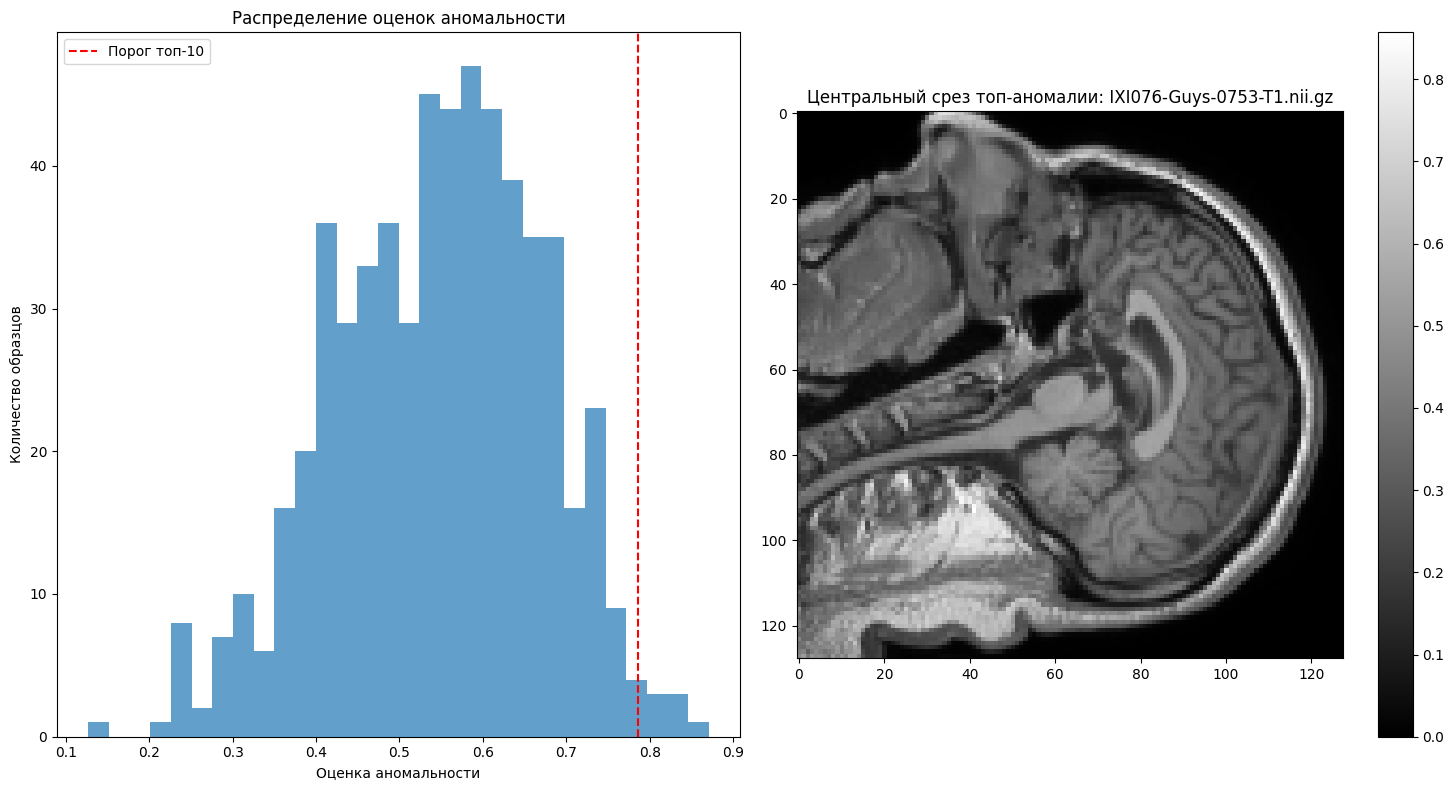

In [9]:
k = 15                  # Количество соседей
n_dim = 10              # Размерность касательного пространства
n_pca = 100             # Количество компонент PCA для снижения размерности
    
anomaly_scores, curvature, holonomy, reconstruction = detect_anomalies(
        mri_data, k=k, n_dim=n_dim, n_pca=n_pca, 
        curvature_weight=0.4, holonomy_weight=0.3, reconstruction_weight=0.3
    )
    
visualize_anomalies(mri_data, file_names, anomaly_scores, top_n=10)
    

results = {
        'file_names': file_names,
        'anomaly_scores': anomaly_scores,
        'curvature': curvature,
        'holonomy': holonomy,
        'reconstruction': reconstruction
    }
    
np.save('mri_fiber_bundle_anomaly_detection.npy', results)

In [23]:
def detect_anomalies_with_fiber_bundles(data, k=15, n_dim=10, n_pca=30, 
                                        curvature_weight=0.4, holonomy_weight=0.3, reconstruction_weight=0.3):
    """
    Обнаружение аномалий с использованием метода расслоенных пространств
    """
    start_time = time.time()
    
    data_reduced = reduce_dimension(data, n_components=n_pca)
    tangent_bases, neighbor_indices = compute_tangent_spaces(data_reduced, k=k, n_dim=n_dim)
    
    connection_forms = compute_connection_forms(tangent_bases, neighbor_indices)
    
    curvature_scores = compute_curvature(data_reduced, tangent_bases, neighbor_indices)
    holonomy_scores = compute_holonomy(tangent_bases, neighbor_indices, connection_forms)
    reconstruction_errors = compute_reconstruction_error(data_reduced, tangent_bases, neighbor_indices)
    
    # Комбинируем метрики с заданными весами
    anomaly_scores = (curvature_weight * curvature_scores + 
                      holonomy_weight * holonomy_scores + 
                      reconstruction_weight * reconstruction_errors)
    
    end_time = time.time()
    print(f"Общее время выполнения: {end_time - start_time:.2f} секунд")
    
    return anomaly_scores, curvature_scores, holonomy_scores, reconstruction_errors

def create_synthetic_anomalies_mri(mri_data, anomaly_ratio=0.2, anomaly_scale=5.0, random_state=42):
    """
    Создает синтетические аномалии в МРТ-снимках для оценки алгоритма.
    
    Args:
        mri_data: Набор МРТ-снимков в формате (n_samples, n_features)
        anomaly_ratio: Доля аномальных образцов
        anomaly_scale: Масштаб аномалий
        random_state: Случайное состояние для воспроизводимости
        
    Returns:
        МРТ-снимки с аномалиями и индексы аномальных образцов
    """
    np.random.seed(random_state)
    mri_data_with_anomalies = mri_data.copy()
    n_samples = mri_data.shape[0]
    
    n_anomalies = int(n_samples * anomaly_ratio)
    anomaly_indices = np.random.choice(n_samples, n_anomalies, replace=False)
    
    for idx in anomaly_indices:
        img_3d = mri_data[idx].reshape(target_shape)
        anomaly_type = np.random.choice(['local_bright', 'local_dark', 'noise', 'structured'])
        
        if anomaly_type == 'local_bright':
            # Создаем яркое пятно в случайном месте
            x_center = np.random.randint(20, target_shape[0]-20)
            y_center = np.random.randint(20, target_shape[1]-20)
            z_center = np.random.randint(10, target_shape[2]-10)
            
            radius = np.random.randint(5, 15)
            
            x, y, z = np.indices((target_shape))
            dist = np.sqrt((x - x_center)**2 + (y - y_center)**2 + (z - z_center)**2)
            anomaly_mask = dist <= radius
            
            img_3d[anomaly_mask] *= anomaly_scale
            
        elif anomaly_type == 'local_dark':
            # Создаем темное пятно в случайном месте
            x_center = np.random.randint(20, target_shape[0]-20)
            y_center = np.random.randint(20, target_shape[1]-20)
            z_center = np.random.randint(10, target_shape[2]-10)
            
            radius = np.random.randint(5, 15)
            
            x, y, z = np.indices((target_shape))
            dist = np.sqrt((x - x_center)**2 + (y - y_center)**2 + (z - z_center)**2)
            anomaly_mask = dist <= radius
            
            img_3d[anomaly_mask] /= anomaly_scale
            
        elif anomaly_type == 'noise':
            noise = np.random.randn(*target_shape) * (np.max(img_3d) - np.min(img_3d)) * 0.1
            img_3d += noise
            
        else:  # 'structured'
            direction = np.random.choice(['x', 'y', 'z'])
            
            if direction == 'x':
                x_start = np.random.randint(0, target_shape[0] - 1)
                width = np.random.randint(5, 20)
                x_end = min(x_start + width, target_shape[0])
                img_3d[x_start:x_end, :, :] *= anomaly_scale
                
            elif direction == 'y':
                y_start = np.random.randint(0, target_shape[1] - 1)
                width = np.random.randint(5, 20)
                y_end = min(y_start + width, target_shape[1])
                img_3d[:, y_start:y_end, :] *= anomaly_scale
                
            else:  # 'z'
                z_start = np.random.randint(0, target_shape[2] - 1)
                width = np.random.randint(3, 10)
                z_end = min(z_start + width, target_shape[2])
                img_3d[:, :, z_start:z_end] *= anomaly_scale
        
        mri_data_with_anomalies[idx] = img_3d.flatten()
    
    return mri_data_with_anomalies, anomaly_indices

def evaluate_fiber_bundle_method(mri_data, num_samples=50, anomaly_ratio=0.3, 
                                anomaly_scale=5.0, k=15, n_dim=10, n_pca=30, random_state=42):
    """
    Оценивает эффективность метода расслоенных пространств на данных с синтетическими аномалиями.
    
    Args:
        mri_data: Исходные МРТ-данные
        num_samples: Количество образцов для анализа
        anomaly_ratio: Доля аномальных образцов
        anomaly_scale: Масштаб аномалий
        k, n_dim, n_pca: Параметры алгоритма
        random_state: Случайное состояние для воспроизводимости
        
    Returns:
        Метрики и результаты алгоритма
    """
    if num_samples < len(mri_data):
        np.random.seed(random_state)
        indices = np.random.choice(len(mri_data), num_samples, replace=False)
        mri_subset = mri_data[indices]
        file_subset = [file_names[i] for i in indices]
    else:
        mri_subset = mri_data
        file_subset = file_names
    
    mri_with_anomalies, anomaly_indices = create_synthetic_anomalies_mri(
        mri_subset, anomaly_ratio=anomaly_ratio, anomaly_scale=anomaly_scale, random_state=random_state
    )
    
    # Метки: 1 для аномалий, 0 для нормальных
    true_labels = np.zeros(len(mri_subset))
    true_labels[anomaly_indices] = 1
    
    anomaly_scores, curvature, holonomy, reconstruction = detect_anomalies_with_fiber_bundles(
        mri_with_anomalies, k=k, n_dim=n_dim, n_pca=n_pca,
        curvature_weight=0.4, holonomy_weight=0.3, reconstruction_weight=0.3
    )
    
    roc_auc = roc_auc_score(true_labels, anomaly_scores)
    precision, recall, _ = precision_recall_curve(true_labels, anomaly_scores)
    pr_auc = auc(recall, precision)
    
    roc_auc_curvature = roc_auc_score(true_labels, curvature)
    roc_auc_holonomy = roc_auc_score(true_labels, holonomy)
    roc_auc_reconstruction = roc_auc_score(true_labels, reconstruction)
    
    print(f"\nРезультаты обнаружения аномалий методом расслоенных пространств:")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    
    print(f"\nROC AUC отдельных компонентов:")
    print(f"Кривизна: {roc_auc_curvature:.4f}")
    print(f"Голономия: {roc_auc_holonomy:.4f}")
    print(f"Ошибка реконструкции: {roc_auc_reconstruction:.4f}")
    
    visualize_performance_curves(true_labels, anomaly_scores, roc_auc, pr_auc)
    
    results = {
        'true_labels': true_labels,
        'anomaly_scores': anomaly_scores,
        'curvature': curvature,
        'holonomy': holonomy,
        'reconstruction': reconstruction,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    }
    
    np.save('mri_fiber_bundle_evaluation.npy', results)
    
    return results

def visualize_performance_curves(true_labels, anomaly_scores, roc_auc, pr_auc):
    """
    Визуализирует кривые ROC и PR для оценки эффективности алгоритма.
    
    Args:
        true_labels: Истинные метки (1 для аномалий, 0 для нормальных)
        anomaly_scores: Оценки аномальности
        roc_auc: Значение ROC AUC
        pr_auc: Значение PR AUC
    """
    plt.figure(figsize=(15, 6))
    
    # ROC-кривая
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(true_labels, anomaly_scores)
    plt.plot(fpr, tpr, lw=2)
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve (AUC = {roc_auc:.4f})', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # PR-кривая
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(true_labels, anomaly_scores)
    plt.plot(recall, precision, lw=2)
    
    # Добавляем линию случайного классификатора
    baseline = np.sum(true_labels) / len(true_labels)
    plt.axhline(y=baseline, color='k', linestyle='--', lw=1, 
               label=f'Random (precision = {baseline:.2f})')
    
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'PR Curve (AUC = {pr_auc:.4f})', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('mri_fiber_bundle_performance.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
if __name__ == "__main__":
    
    evaluation_params = {
        'num_samples': 50,        # Ограничиваем количество снимков для ускорения
        'anomaly_ratio': 0.3,     # Доля аномалий
        'anomaly_scale': 300.0,   # Масштаб аномалий
        'k': 5,                   # Количество соседей
        'n_dim': n_dim,           # Размерность касательного пространства
        'n_pca': 50,              # Количество компонент PCA
        'random_state': 42        # Для воспроизводимости
    }
    
    evaluation_results = evaluate_fiber_bundle_method(mri_data, **evaluation_params)

Снижение размерности с 1048576 до 50...
